In [60]:
import warnings
warnings.filterwarnings('ignore')
import keras
from keras.datasets import mnist #MINIST DATABASE 60.000 imagens de treino e 10.000 de teste

In [61]:
(x_treino, y_treino), (x_teste, y_teste) = mnist.load_data() #padrao de importação dos dados

In [62]:
y_treino.shape

(60000,)

In [63]:
from keras.utils import np_utils
y_treino_convertido = np_utils.to_categorical(y_treino) #convertendo a coluna de valores em uma matriz de classes #10 colunas
y_teste_convertido = np_utils.to_categorical(y_teste)

In [64]:
y_treino_convertido

array([[0.00, 0.00, 0.00, ..., 0.00, 0.00, 0.00],
       [1.00, 0.00, 0.00, ..., 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, ..., 0.00, 0.00, 0.00],
       ...,
       [0.00, 0.00, 0.00, ..., 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, ..., 0.00, 0.00, 0.00],
       [0.00, 0.00, 0.00, ..., 0.00, 1.00, 0.00]], dtype=float32)

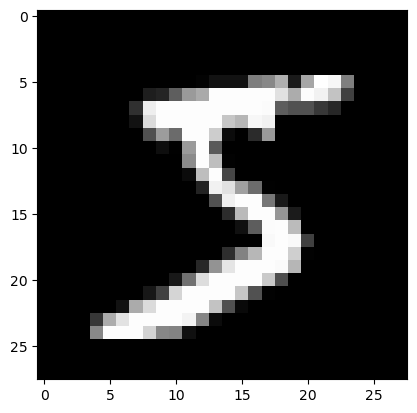

In [65]:
import matplotlib.pyplot as plt
plt.imshow(x_treino[0], cmap='gray')

In [66]:
x_treino[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [67]:
from keras.models import Sequential
from keras.layers import Dense, Activation

In [68]:
x_treino.shape

(60000, 28, 28)

In [69]:
x_treino_remodelado = x_treino.reshape((60000, 784)) #28 x 28
x_teste_remodelado = x_teste.reshape((10000, 784))

In [70]:
x_treino_normalizado = x_treino_remodelado.astype('float32') / 255 #dividir todos paras 255

In [71]:
x_teste_normalizado = x_teste_remodelado.astype('float32') / 255

In [72]:
x_treino_normalizado[0]

array([0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00,
       0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00, 0.

In [73]:
modelo = Sequential()
modelo.add(Dense(30, input_dim=784, kernel_initializer='normal', activation='relu')) #Entrada & primeira camada oculta
modelo.add(Dense(30, kernel_initializer='normal', activation='relu')) #Segunda camada oculta
modelo.add(Dense(10, kernel_initializer='normal', activation='softmax')) #Saida

In [74]:
from keras.optimizers import SGD
otimizador = SGD()

In [75]:
modelo.compile(loss='categorical_crossentropy', optimizer=otimizador, metrics=['acc']) #"acc" é a métrica de acurácia
historico = modelo.fit(x_treino_normalizado, y_treino_convertido, epochs=200, batch_size=100, validation_data=(x_teste_normalizado, y_teste_convertido), verbose=1)

Epoch 1/200
600/600 [==============================] - 1s 2ms/step - loss: 2.2940 - acc: 0.1701 - val_loss: 2.2785 - val_acc: 0.2317
Epoch 2/200
600/600 [==============================] - 1s 1ms/step - loss: 2.1993 - acc: 0.3552 - val_loss: 1.9800 - val_acc: 0.4592
Epoch 3/200
600/600 [==============================] - 1s 1ms/step - loss: 1.4592 - acc: 0.5953 - val_loss: 0.9722 - val_acc: 0.7268
Epoch 4/200
600/600 [==============================] - 1s 1ms/step - loss: 0.7569 - acc: 0.7899 - val_loss: 0.5920 - val_acc: 0.8354
Epoch 5/200
600/600 [==============================] - 1s 1ms/step - loss: 0.5373 - acc: 0.8500 - val_loss: 0.4715 - val_acc: 0.8686
Epoch 6/200
600/600 [==============================] - 1s 1ms/step - loss: 0.4550 - acc: 0.8708 - val_loss: 0.4201 - val_acc: 0.8814
Epoch 7/200
600/600 [==============================] - 1s 1ms/step - loss: 0.4155 - acc: 0.8812 - val_loss: 0.3886 - val_acc: 0.8893
Epoch 8/200
600/600 [==============================] - 1s 1ms/step - 

600/600 [==============================] - 1s 1ms/step - loss: 0.1206 - acc: 0.9651 - val_loss: 0.1411 - val_acc: 0.9589
Epoch 63/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1192 - acc: 0.9655 - val_loss: 0.1411 - val_acc: 0.9590
Epoch 64/200
600/600 [==============================] - 1s 2ms/step - loss: 0.1179 - acc: 0.9657 - val_loss: 0.1385 - val_acc: 0.9603
Epoch 65/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1165 - acc: 0.9665 - val_loss: 0.1382 - val_acc: 0.9597
Epoch 66/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1150 - acc: 0.9668 - val_loss: 0.1376 - val_acc: 0.9598
Epoch 67/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1138 - acc: 0.9672 - val_loss: 0.1353 - val_acc: 0.9603
Epoch 68/200
600/600 [==============================] - 1s 1ms/step - loss: 0.1126 - acc: 0.9676 - val_loss: 0.1356 - val_acc: 0.9606
Epoch 69/200
600/600 [==============================] - 1s 1ms/step - loss:

600/600 [==============================] - 1s 1ms/step - loss: 0.0692 - acc: 0.9800 - val_loss: 0.1119 - val_acc: 0.9681
Epoch 124/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0686 - acc: 0.9804 - val_loss: 0.1121 - val_acc: 0.9679
Epoch 125/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0682 - acc: 0.9804 - val_loss: 0.1115 - val_acc: 0.9669
Epoch 126/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0674 - acc: 0.9809 - val_loss: 0.1105 - val_acc: 0.9678
Epoch 127/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0673 - acc: 0.9810 - val_loss: 0.1131 - val_acc: 0.9668
Epoch 128/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0667 - acc: 0.9812 - val_loss: 0.1109 - val_acc: 0.9675
Epoch 129/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0662 - acc: 0.9812 - val_loss: 0.1120 - val_acc: 0.9665
Epoch 130/200
600/600 [==============================] - 1s 1ms/step 

Epoch 184/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0464 - acc: 0.9872 - val_loss: 0.1118 - val_acc: 0.9690
Epoch 185/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0461 - acc: 0.9874 - val_loss: 0.1116 - val_acc: 0.9696
Epoch 186/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0456 - acc: 0.9874 - val_loss: 0.1116 - val_acc: 0.9696
Epoch 187/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0455 - acc: 0.9874 - val_loss: 0.1132 - val_acc: 0.9684
Epoch 188/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0452 - acc: 0.9877 - val_loss: 0.1112 - val_acc: 0.9699
Epoch 189/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0446 - acc: 0.9873 - val_loss: 0.1112 - val_acc: 0.9695
Epoch 190/200
600/600 [==============================] - 1s 1ms/step - loss: 0.0447 - acc: 0.9878 - val_loss: 0.1110 - val_acc: 0.9698
Epoch 191/200
600/600 [==============================] 

In [76]:
historico.history[ 'acc' ]

[0.17006666958332062,
 0.35519999265670776,
 0.595300018787384,
 0.7898833155632019,
 0.8500000238418579,
 0.8708000183105469,
 0.8812166452407837,
 0.8885833621025085,
 0.893750011920929,
 0.8977000117301941,
 0.9009833335876465,
 0.9046833515167236,
 0.9075666666030884,
 0.9094666838645935,
 0.9130333065986633,
 0.9156666398048401,
 0.9175000190734863,
 0.9206333160400391,
 0.9222000241279602,
 0.9243833422660828,
 0.926633358001709,
 0.9287333488464355,
 0.930983304977417,
 0.9329666495323181,
 0.9346333146095276,
 0.9358000159263611,
 0.9383833408355713,
 0.9386333227157593,
 0.9412500262260437,
 0.942383348941803,
 0.9435833096504211,
 0.9446666836738586,
 0.9461666941642761,
 0.9472666382789612,
 0.9480999708175659,
 0.9489833116531372,
 0.9495166540145874,
 0.9503499865531921,
 0.9515833258628845,
 0.9525333046913147,
 0.9535999894142151,
 0.9538166522979736,
 0.9552666544914246,
 0.9553333520889282,
 0.9567499756813049,
 0.956933319568634,
 0.9580666422843933,
 0.95831668376922

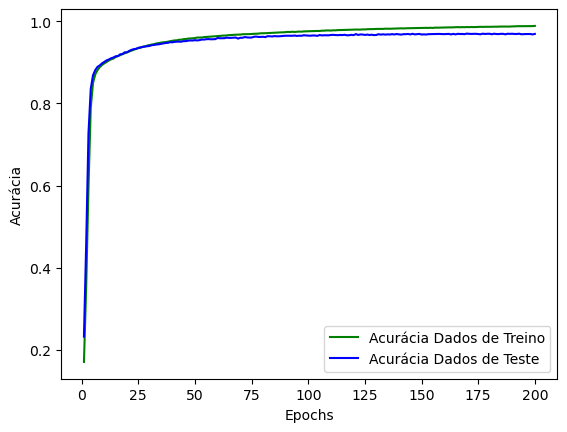

In [77]:
acuracia_treino = historico.history['acc']
acuracia_teste = historico.history['val_acc']

epochs = range(1, len(acuracia_treino)+1)

plt.plot(epochs, acuracia_treino, '-g', label='Acurácia Dados de Treino') # g é a cor
plt.plot(epochs, acuracia_teste, '-b', label='Acurácia Dados de Teste')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Acurácia')
plt.show()